# 📊 Exploration des données de CV (EDA)
L'objectif de ce notebook est de comprendre la structure, la distribution et les relations entre les différentes caractéristiques des candidats (âge, expérience, niveau de langue, etc.).

In [1]:
# Importation des librairies standards pour l'analyse de données
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration de l'affichage des graphiques
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 1. Chargement et Aperçu des Données

In [2]:
# Remplacer 'chemin_vers_le_fichier.csv' par le nom de votre fichier
df = pd.read_csv('data/cv_dataset.csv')

# Affichage des 5 premières lignes
df.head()

# Dimensions du dataset (lignes, colonnes)
print(f"Le dataset contient {df.shape[0]} lignes et {df.shape[1]} colonnes.")

Le dataset contient 205 lignes et 21 colonnes.


## 2. Structure et Valeurs Manquantes
Vérifions les types de données de chaque colonne et cherchons s'il y a des valeurs nulles (NaN) qui nécessiteraient un nettoyage.

In [3]:
# Informations générales (types de variables et valeurs non nulles)
df.info()

# Comptage des valeurs manquantes par colonne
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

if not missing_values.empty:
    print("\nValeurs manquantes trouvées :")
    print(missing_values)
else:
    print("\nAucune valeur manquante dans le dataset !")

# Statistiques descriptives pour les variables numériques
display(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   cv_id                    205 non-null    str    
 1   age                      205 non-null    int64  
 2   distance_ville_haute_km  90 non-null     float64
 3   target_role              205 non-null    str    
 4   total_experience_years   205 non-null    float64
 5   total_gap_months         205 non-null    int64  
 6   nb_gaps                  205 non-null    int64  
 7   education_degree         205 non-null    str    
 8   education_field          205 non-null    str    
 9   education_school         205 non-null    str    
 10  education_score          205 non-null    int64  
 11  skills                   205 non-null    str    
 12  certifications           205 non-null    str    
 13  number_of_experiences    205 non-null    int64  
 14  lang_fr                  205 non-null

,age,distance_ville_haute_km,total_experience_years,total_gap_months,nb_gaps,education_score,number_of_experiences,lang_fr,lang_en,lang_de,lang_es,lang_it,lang_other_score_sum,passed_next_stage
count,205.000000,90.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,199.000000
mean,31.726829,6134.082111,5.641463,12.424390,0.873171,3.429268,1.902439,1.219512,5.541463,1.039024,0.468293,0.448780,0.682927,0.251256
std,5.088772,3278.993812,3.248648,13.243585,0.898535,0.496183,0.891267,2.181834,0.499498,1.997164,1.289178,1.265516,1.721249,0.434830
min,21.000000,157.630000,0.400000,0.000000,0.000000,3.000000,1.000000,0.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28.000000,5224.827500,2.700000,0.000000,0.000000,3.000000,1.000000,0.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,32.000000,8038.040000,5.300000,10.000000,1.000000,3.000000,2.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,35.000000,8203.720000,8.000000,24.000000,2.000000,4.000000,3.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.500000
max,44.000000,8429.310000,18.200000,42.000000,2.000000,4.000000,3.000000,6.000000,6.000000,6.000000,4.000000,4.000000,5.000000,1.000000


## 3. Analyse Univariée (Distributions)
Regardons comment se répartissent les caractéristiques principales des candidats comme l'âge et les années d'expérience.

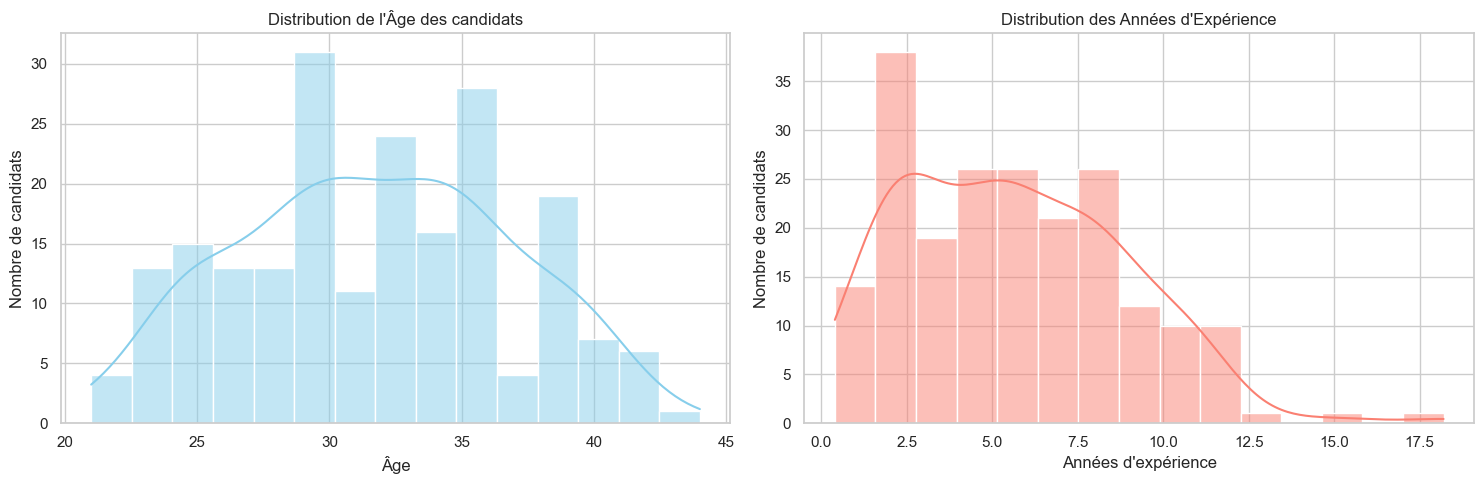

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Distribution de l'âge
sns.histplot(df['age'], bins=15, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title("Distribution de l'Âge des candidats")
axes[0].set_xlabel("Âge")
axes[0].set_ylabel("Nombre de candidats")

# Distribution de l'expérience totale
sns.histplot(df['total_experience_years'], bins=15, kde=True, ax=axes[1], color='salmon')
axes[1].set_title("Distribution des Années d'Expérience")
axes[1].set_xlabel("Années d'expérience")
axes[1].set_ylabel("Nombre de candidats")

plt.tight_layout()
plt.show()

## 4. Analyse Bivariée (Relations entre les variables)
Existe-t-il une corrélation forte entre l'âge et l'expérience ? Quels types de profils postulent pour quels rôles ?

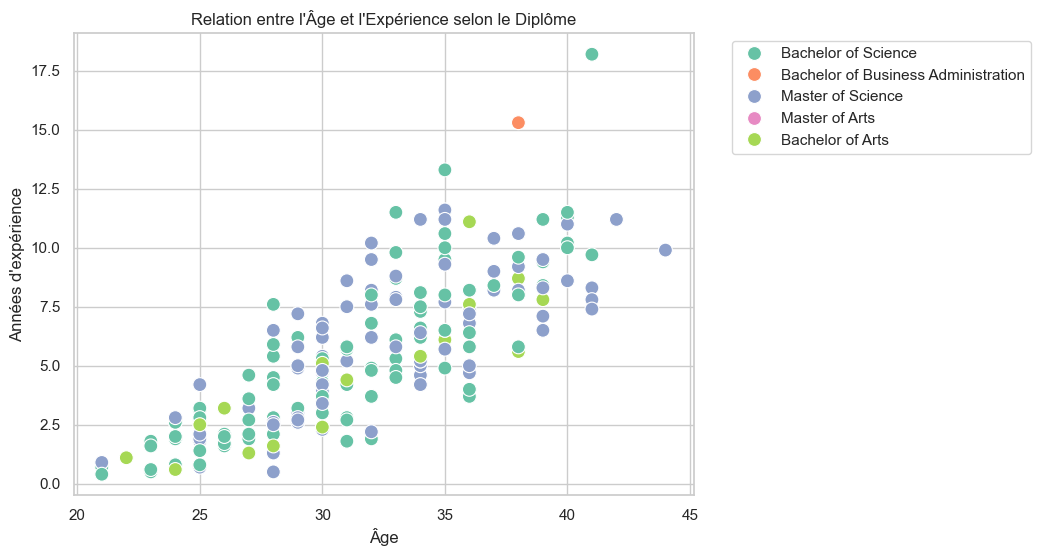

C:\Users\bourg\AppData\Local\Temp\ipykernel_8708\3502066684.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=exp_by_role.values, y=exp_by_role.index, palette='viridis')


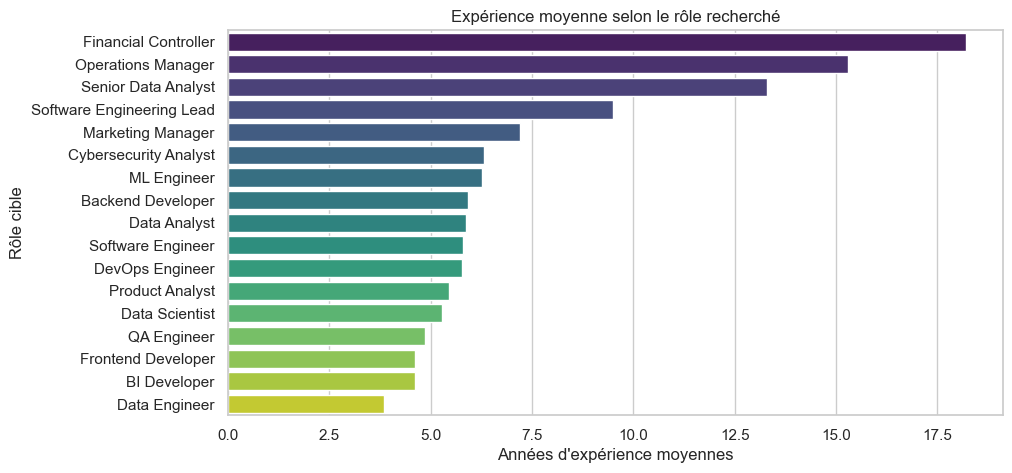

In [5]:
# Relation Âge vs Expérience
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='age', y='total_experience_years', hue='education_degree', s=100, palette='Set2')
plt.title("Relation entre l'Âge et l'Expérience selon le Diplôme")
plt.xlabel("Âge")
plt.ylabel("Années d'expérience")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# Expérience moyenne par Rôle cible
plt.figure(figsize=(10, 5))
exp_by_role = df.groupby('target_role')['total_experience_years'].mean().sort_values(ascending=False)
sns.barplot(x=exp_by_role.values, y=exp_by_role.index, palette='viridis')
plt.title("Expérience moyenne selon le rôle recherché")
plt.xlabel("Années d'expérience moyennes")
plt.ylabel("Rôle cible")
plt.show()

## 5. Analyse des Compétences Linguistiques
Puisque le jeu de données contient des scores pour différentes langues (FR, EN, DE, LU, ES, IT), analysons le niveau linguistique global des candidats.

C:\Users\bourg\AppData\Local\Temp\ipykernel_8708\1244226416.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mean_langs.values, y=mean_langs.index, palette='magma')


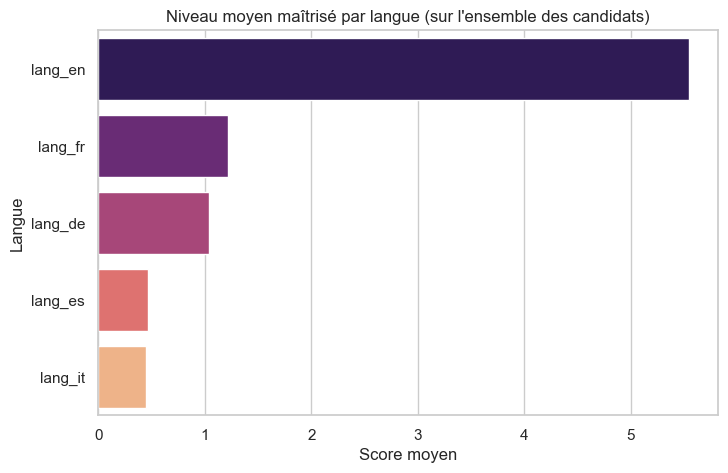

In [6]:
# Sélection des colonnes de langues
lang_cols = ['lang_fr', 'lang_en', 'lang_de', 'lang_es', 'lang_it']

# Calcul du niveau moyen pour chaque langue
mean_langs = df[lang_cols].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=mean_langs.values, y=mean_langs.index, palette='magma')
plt.title("Niveau moyen maîtrisé par langue (sur l'ensemble des candidats)")
plt.xlabel("Score moyen")
plt.ylabel("Langue")
plt.show()

## 6. Analyse de la Matrice de Corrélation
Pour finir, nous pouvons générer une matrice de corrélation pour repérer mathématiquement les relations linéaires entre toutes nos variables numériques (ex: plus on est âgé, plus on habite loin ?).

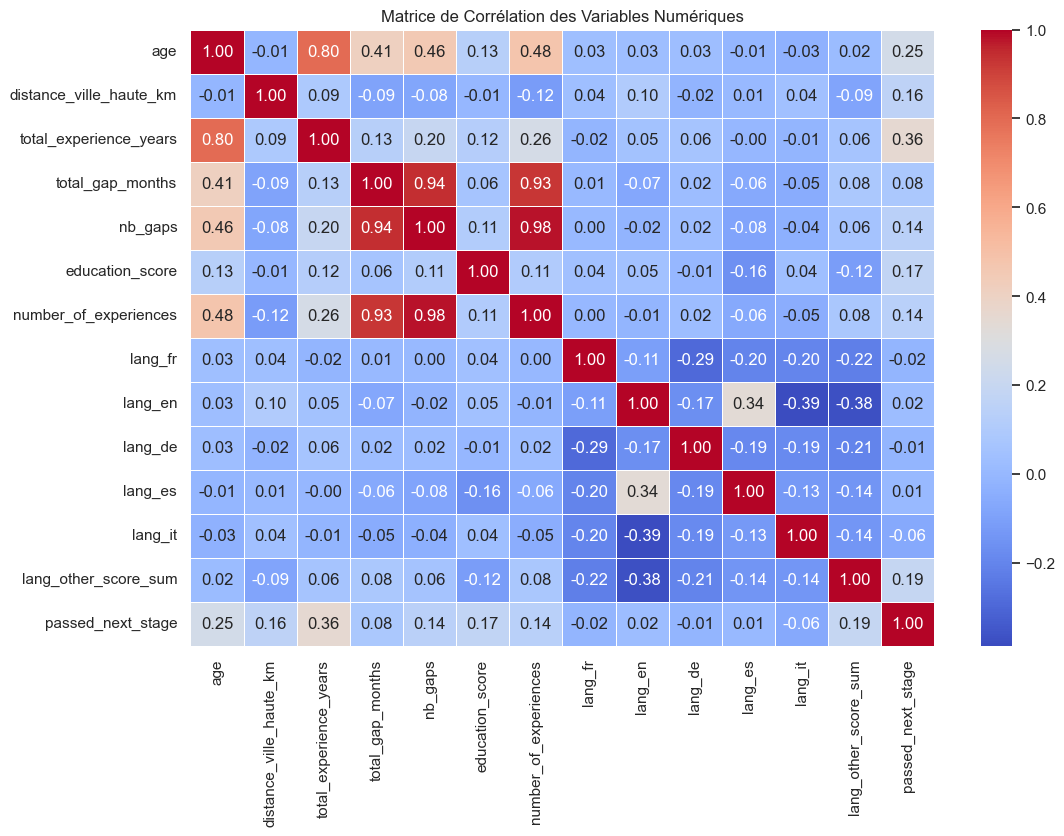

In [7]:
# Sélectionner uniquement les colonnes numériques
num_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(12, 8))
# Création d'une carte de chaleur (heatmap) des corrélations
sns.heatmap(num_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title("Matrice de Corrélation des Variables Numériques")
plt.show()